### name- Nandini G40 AIML 
### E-COMMERCE-RECCOMENDATION SYSTEM (CASE STUDY)


#### Introduction
This project aims to build an intelligent e-commerce recommendation system using machine learning techniques. The system analyzes customer browsing behavior, purchase history, product ratings, and demographic information to provide personalized recommendations and business insights.

The project implements three machine learning approaches:
- **Regression** to predict product ratings.
- **Classification** to predict the likelihood of a customer purchasing a product.
- **Clustering** to segment customers based on their shopping behavior.

Additionally, hyperparameter tuning is performed to improve model performance. The results help the e-commerce business recommend products more effectively, identify potential buyers, understand customer segments, and support data-driven marketing strategies.

### IMPORT REQUIRED LIBRARIES 

In [101]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


from sklearn.linear_model import LinearRegression, Ridge

from sklearn.linear_model import LogisticRegression


from sklearn.cluster import KMeans


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    silhouette_score
)


from sklearn.model_selection import GridSearchCV


import joblib

In [102]:
import os

print(os.listdir("dataset"))

['e-commerce-data.csv']


In [103]:
import os

print(os.listdir("dataset"))

['e-commerce-data.csv']


### Load the Dataset


In [104]:
import pandas as pd

df = pd.read_csv(
    "dataset/e-commerce-data.csv"
)

df.head()

,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,U2824,P13278,Beauty,1299.97,3.3,44.6,21,1,1,26,Other,Mumbai,0,10240.20
1,U1434,P83563,Books,3608.50,4.3,27.2,7,0,1,62,Other,Pune,1,11150.27
2,U6574,P46421,Home,1155.04,3.8,6.3,12,0,0,39,Male,Mumbai,1,10208.63
3,U7201,P20328,Beauty,4164.08,4.4,4.6,22,0,0,57,Female,Chennai,0,28887.70
4,U7227,P46434,Grocery,3214.85,2.5,13.0,11,0,0,41,Male,Kolkata,1,10878.67


#### DATA PREPROCESSING

In [105]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()


X = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Discount_Applied",
    "Age",
    "Total_Spending"
]]

y = df["Rating"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData preprocessing completed successfully!")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Missing Values:
User_ID               0
Product_ID            0
Category              0
Price                 0
Rating                0
Browsing_Time         0
Previous_Purchases    0
Cart_Addition         0
Purchase_Status       0
Age                   0
Gender                0
Location              0
Discount_Applied      0
Total_Spending        0
dtype: int64

Duplicate Records: 0

Data preprocessing completed successfully!
Training Data Shape: (16000, 6)
Testing Data Shape: (4000, 6)


#### Exploratory Data Analysis

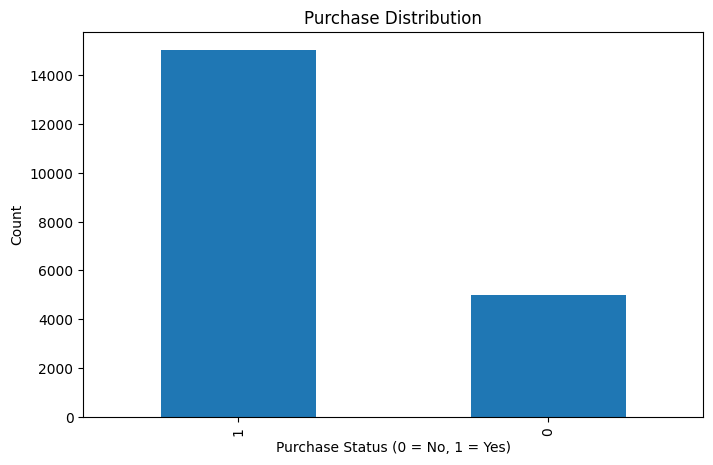

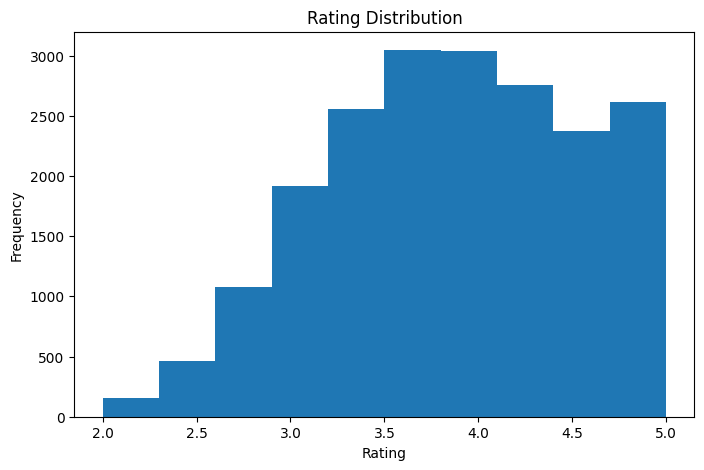

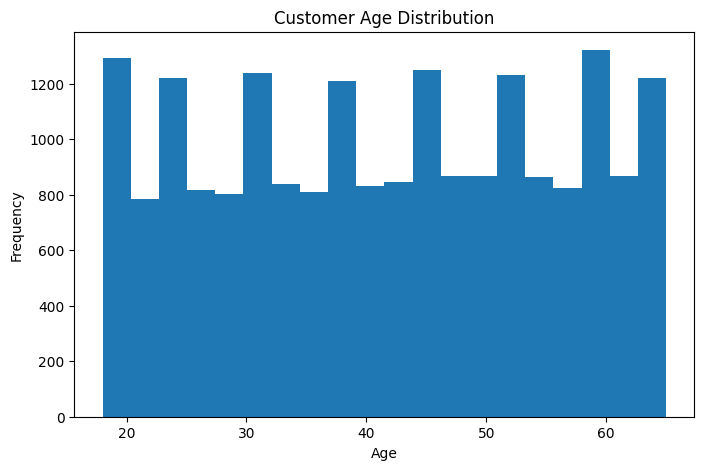

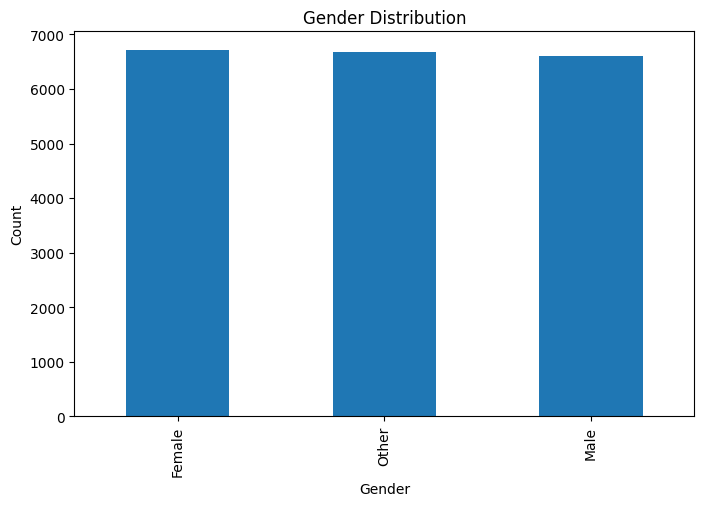

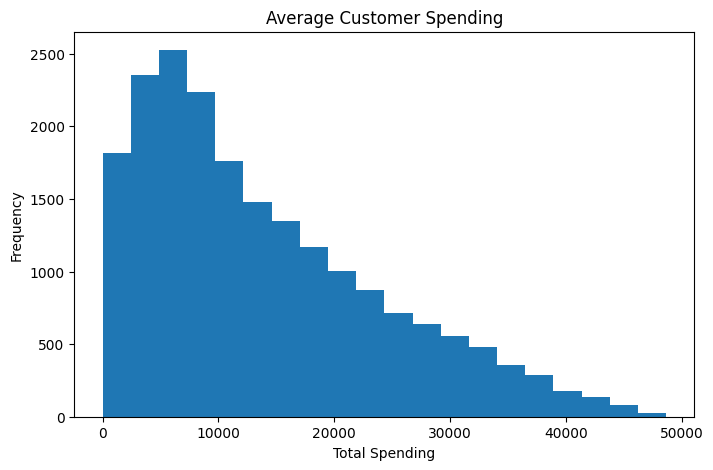

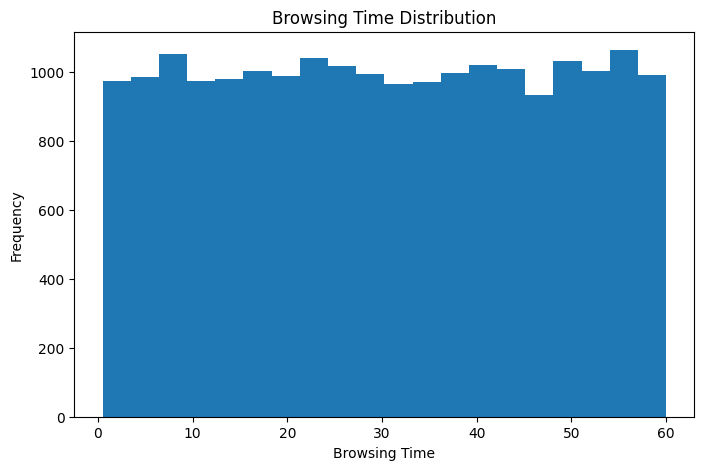

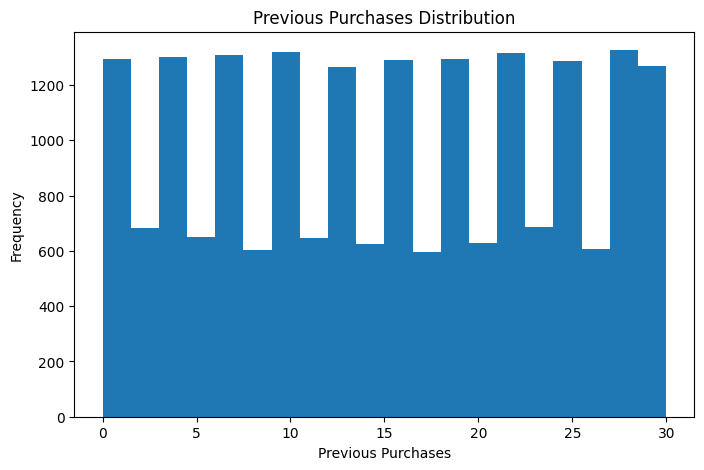

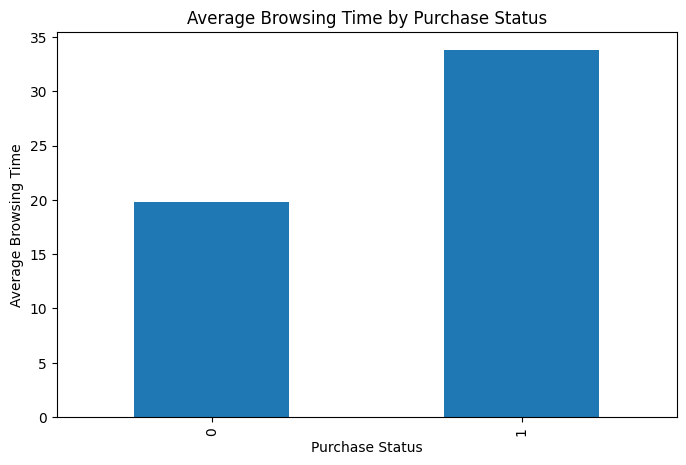

In [106]:



# 1. Purchase Distribution

plt.figure(figsize=(8,5))

df["Purchase_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Purchase Distribution")
plt.xlabel("Purchase Status (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.savefig(
    "screenshots/01_purchase_distribution.png",
    bbox_inches="tight"
)

plt.show()



# 2. Rating Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Rating"],
    bins=10
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig(
    "screenshots/02_rating_distribution.png",
    bbox_inches="tight"
)

plt.show()



# 3. Customer Age Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig(
    "screenshots/03_customer_age_distribution.png",
    bbox_inches="tight"
)

plt.show()



# 4. Gender Distribution

plt.figure(figsize=(8,5))

df["Gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig(
    "screenshots/04_gender_distribution.png",
    bbox_inches="tight"
)

plt.show()



# 5. Average Spending

plt.figure(figsize=(8,5))

plt.hist(
    df["Total_Spending"],
    bins=20
)

plt.title("Average Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")

plt.savefig(
    "screenshots/06_average_spending.png",
    bbox_inches="tight"
)

plt.show()



# 6. Browsing Time Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Browsing_Time"],
    bins=20
)

plt.title("Browsing Time Distribution")
plt.xlabel("Browsing Time")
plt.ylabel("Frequency")

plt.savefig(
    "screenshots/07_browsing_time.png",
    bbox_inches="tight"
)

plt.show()



# 7. Previous Purchases Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Previous_Purchases"],
    bins=20
)

plt.title("Previous Purchases Distribution")
plt.xlabel("Previous Purchases")
plt.ylabel("Frequency")

plt.savefig(
    "screenshots/08_previous_purchases.png",
    bbox_inches="tight"
)

plt.show()



# 8. Average Browsing Time by Purchase Status

plt.figure(figsize=(8,5))

df.groupby(
    "Purchase_Status"
)["Browsing_Time"].mean().plot(
    kind="bar"
)

plt.title(
    "Average Browsing Time by Purchase Status"
)

plt.xlabel(
    "Purchase Status"
)

plt.ylabel(
    "Average Browsing Time"
)

plt.savefig(
    "screenshots/10_average_browsing_time_purchase_status.png",
    bbox_inches="tight"
)

plt.show()

### Data Exploration

In [107]:
df.columns

Index(['User_ID', 'Product_ID', 'Category', 'Price', 'Rating', 'Browsing_Time',
       'Previous_Purchases', 'Cart_Addition', 'Purchase_Status', 'Age',
       'Gender', 'Location', 'Discount_Applied', 'Total_Spending'],
      dtype='str')

In [108]:
df.isnull().sum()

User_ID               0
Product_ID            0
Category              0
Price                 0
Rating                0
Browsing_Time         0
Previous_Purchases    0
Cart_Addition         0
Purchase_Status       0
Age                   0
Gender                0
Location              0
Discount_Applied      0
Total_Spending        0
dtype: int64

In [109]:
df.duplicated().sum()


np.int64(0)

In [110]:
df.describe()

,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Discount_Applied,Total_Spending
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2535.306077,3.819870,30.31193,14.966750,0.578750,0.751100,41.667550,0.498150,13845.360542
std,1420.577664,0.680608,17.20280,8.970299,0.493772,0.432387,13.873448,0.500009,10328.725179
min,100.260000,2.000000,0.50000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000
25%,1294.122500,3.300000,15.40000,7.000000,0.000000,1.000000,30.000000,0.000000,5633.882500
50%,2537.650000,3.800000,30.20000,15.000000,1.000000,1.000000,42.000000,0.000000,11208.070000
75%,3765.315000,4.300000,45.20000,23.000000,1.000000,1.000000,54.000000,1.000000,20280.672500
max,4999.750000,5.000000,60.00000,30.000000,1.000000,1.000000,65.000000,1.000000,48642.530000


### Part A: Regression — Rating Prediction

The objective of this section is to build a regression model that predicts the rating a customer is likely to give to a product based on customer behavior and product-related features.


In [111]:

X = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Discount_Applied",
    "Age",
    "Total_Spending"
]]

y = df["Rating"]

print("Features Selected Successfully!")

Features Selected Successfully!


In [112]:
y = df["Rating"]

### Train-Test Split
Before training the regression model, the dataset is divided into two parts: a training set and a testing set. The training set is used to train the machine learning model, while the testing set is used to evaluate how well the model performs on unseen data.



In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (16000, 6)
Testing Shape : (4000, 6)


#### Feature scaling 

In [114]:
rating_scaler = StandardScaler()

X_train = rating_scaler.fit_transform(X_train)
X_test = rating_scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


##### Train the Linear Regression Model

In [115]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


#### PREDICT RATING 

In [116]:
y_pred = reg_model.predict(X_test)

print("First 5 Predicted Ratings:")
print(y_pred[:5])

First 5 Predicted Ratings:
[4.39120219 3.73017119 4.22678346 3.85181005 3.97300683]


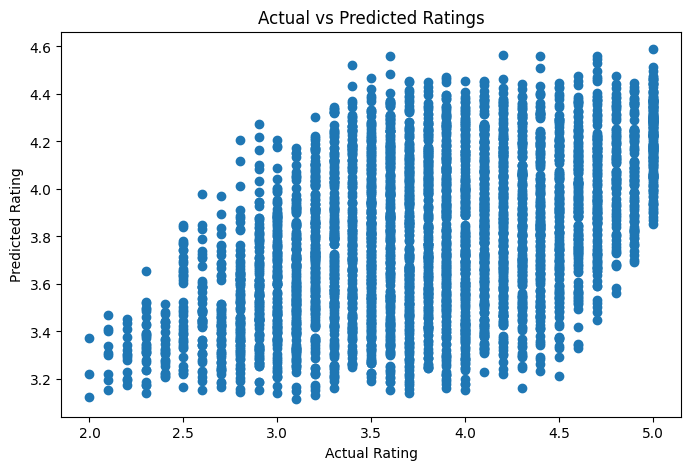

In [117]:
plt.figure(figsize=(8,5))


plt.scatter(
    y_test,
    y_pred
)


plt.xlabel(
    "Actual Rating"
)


plt.ylabel(
    "Predicted Rating"
)


plt.title(
    "Actual vs Predicted Ratings"
)


plt.savefig(
    "screenshots/12_actual_prediction.png",
    bbox_inches="tight"
)


plt.show()

#### Evaluation matrix 

In [118]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.502868463799663
MSE : 0.3469599426594125
RMSE: 0.5890330573570659
R² Score: 0.22796468498160416


#### EVALUATION MATRIX 


| Metric       |     Value | Interpretation                                                                                           |
| ------------ | --------: | -------------------------------------------------------------------------------------------------------- |
| **MAE**      | **0.503** | On average, the predicted rating differs from the actual rating by about **0.5 stars**.                  |
| **MSE**      | **0.347** | The average squared prediction error is 0.347.                                                           |
| **RMSE**     | **0.589** | The prediction error is approximately **0.59 rating points**, which is on the same scale as the ratings. |
| **R² Score** | **0.228** | The model explains about **22.8%** of the variation in customer ratings.                                 |


In [119]:
os.makedirs("Models", exist_ok=True)

joblib.dump(
    reg_model,
    "Models/regression_model.pkl"
)

joblib.dump(
    rating_scaler,
    "Models/rating_scaler.pkl"
)

print("Regression model and scaler saved successfully!")

Regression model and scaler saved successfully!


In [120]:
[
'regression_model.pkl',
'rating_scaler.pkl'
]

['regression_model.pkl', 'rating_scaler.pkl']

##### Part B: Classification – Purchase Likelihood Prediction

The objective of this section is to build a Logistic Regression model that predicts whether a customer is likely to purchase a product. The target variable is Purchase_Status, where 1 indicates that the customer purchased the product and 0 indicates that the customer did not purchase it.

### Step 1 : Select Features and Target

In [121]:

X = df[[
    "Browsing_Time",
    "Cart_Addition",
    "Previous_Purchases",
    "Rating",
    "Price",
    "Discount_Applied",
    "Total_Spending"
]]

y = df["Purchase_Status"]

print("Features and Target Selected Successfully!")

Features and Target Selected Successfully!


#### Step 2 : Train-Test Split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (16000, 7)
Testing Shape : (4000, 7)


#### Step 3: Feature Scaling

In [123]:
purchase_scaler = StandardScaler()

X_train = purchase_scaler.fit_transform(X_train)

X_test = purchase_scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


#### Step 4: Train Logistic Regression

In [124]:
log_model = LogisticRegression(random_state=42)

log_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

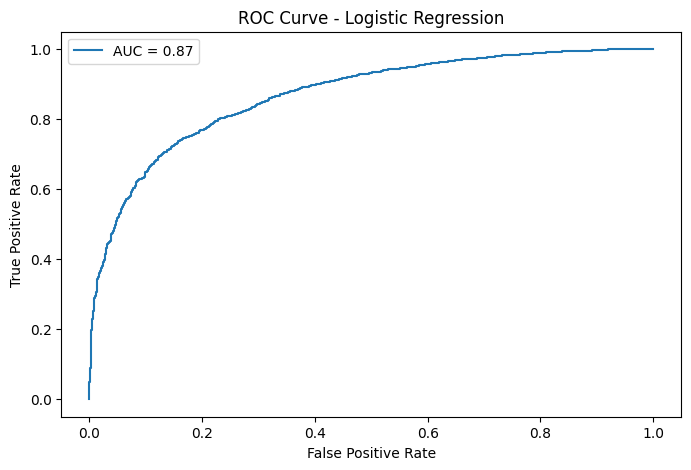

In [125]:
from sklearn.metrics import roc_curve, auc

y_probability = log_model.predict_proba(
    X_test
)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    y_probability
)


roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve - Logistic Regression"
)


plt.legend()


# Save image
plt.savefig(
    "screenshots/14_ROC_Curve.png",
    bbox_inches="tight"
)


plt.show()

#### Step 5: Make Predictions

In [126]:

y_pred = log_model.predict(X_test)

y_prob = log_model.predict_proba(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[1 0 1 0 1]


#### Step 6: Show Purchase Probability

In [127]:
print("Purchase Probability for First Customer")

print("No Purchase :", round(y_prob[0][0] * 100, 2), "%")

print("Purchase :", round(y_prob[0][1] * 100, 2), "%")

Purchase Probability for First Customer
No Purchase : 1.79 %
Purchase : 98.21 %


#### Step 7: Evaluate the Model

In [128]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_pred))

Accuracy : 0.824
Precision : 0.8579918673756647
Recall : 0.9164717674574006
F1 Score : 0.8862681744749596
ROC-AUC : 0.732813838048462


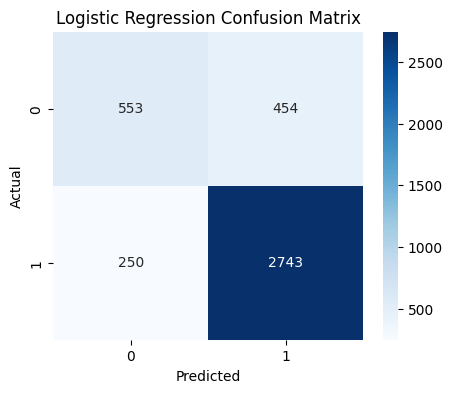

In [129]:



from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(5,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Logistic Regression Confusion Matrix"
)
plt.savefig(
    "screenshots/confusion matrix.png",
    bbox_inches="tight"
)


plt.show()


#### EVALUATION MATRIX 

| Metric        | Your Value | Interpretation                                                                                                  |
| ------------- | ---------: | --------------------------------------------------------------------------------------------------------------- |
| **Accuracy**  |  **82.4%** | The model correctly predicted the purchase status for 82.4% of customers.                                       |
| **Precision** |  **85.8%** | When the model predicted that a customer would purchase, it was correct about 85.8% of the time.                |
| **Recall**    |  **91.6%** | The model successfully identified 91.6% of the customers who actually made a purchase.                          |
| **F1-Score**  |  **88.6%** | The model maintains a strong balance between precision and recall.                                              |
| **ROC-AUC**   |  **73.3%** | The model has a good ability to distinguish between customers who are likely to purchase and those who are not. |


In [130]:
os.makedirs("Models", exist_ok=True)

joblib.dump(
    log_model,
    "Models/logistic_model.pkl"
)

joblib.dump(
    purchase_scaler,
    "Models/purchase_scaler.pkl"
)

print("Logistic Regression model and scaler saved successfully!")

Logistic Regression model and scaler saved successfully!


In [131]:
os.listdir("Models")

['all models',
 'cluster_scaler.pkl',
 'kmeans_model.pkl',
 'logistic_model.pkl',
 'purchase_scaler.pkl',
 'rating_scaler.pkl',
 'regression_model.pkl']

#### Part C: Clustering — Customer Segmentation

The objective of this section is to segment customers into different groups based on their shopping behavior using the K-Means Clustering algorithm. Customer segmentation helps businesses identify groups

### Step 1 : Select Features

In [132]:

cluster_data = df[[
    "Browsing_Time",
    "Previous_Purchases",
    "Rating",
    "Total_Spending",
    "Cart_Addition",
    "Discount_Applied"
]]

In [133]:


cluster_data = df[[
    "Browsing_Time",
    "Previous_Purchases",
    "Rating",
    "Total_Spending",
    "Cart_Addition",
    "Discount_Applied"
]]



from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

print("Data scaled successfully!")

Data scaled successfully!


#### Step 2: Scale the Data

In [134]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

print("Data scaled successfully!")

Data scaled successfully!


In [135]:
from sklearn.cluster import KMeans

In [136]:
import matplotlib.pyplot as plt

#### Step 3: Elbow Method

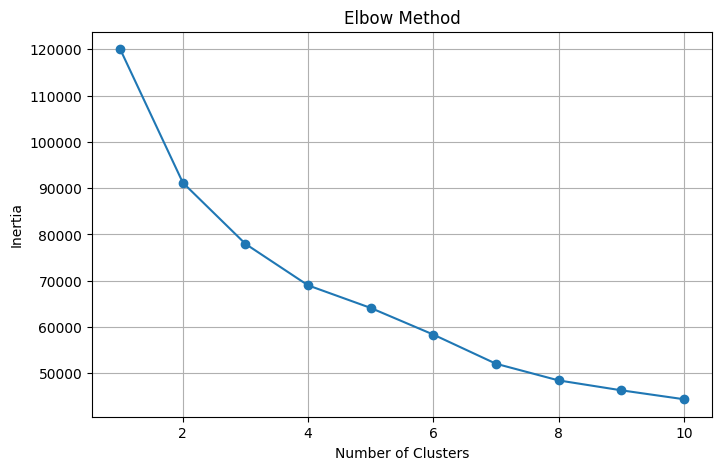

In [137]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.savefig(
    "screenshots/_Elbow_Method.png",
    bbox_inches="tight"
)
plt.show()

In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Select features for clustering

cluster_data = df[[
    "Browsing_Time",
    "Previous_Purchases",
    "Rating",
    "Total_Spending",
    "Cart_Addition",
    "Discount_Applied"
]]


# Scale features

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)


# Create K-Means model

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)


# Add cluster labels to dataframe

df["Cluster"] = kmeans.fit_predict(
    cluster_scaled
)


print("Cluster column created successfully ✅")


# Check clusters

print(df["Cluster"].value_counts())

Cluster column created successfully ✅
Cluster
0    5743
1    5023
3    4972
2    4262
Name: count, dtype: int64


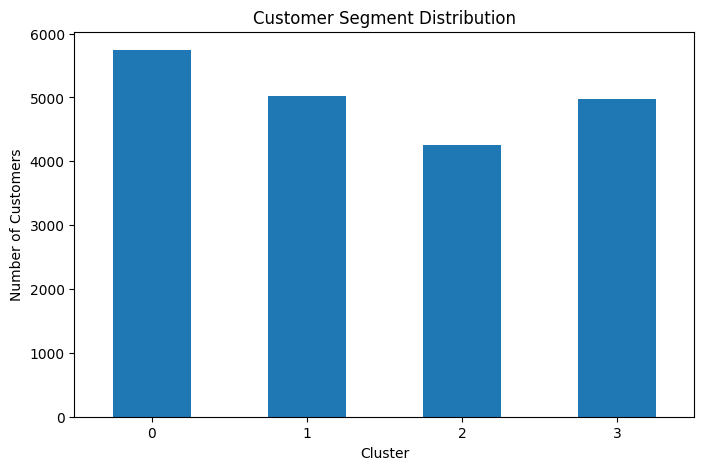

In [139]:
plt.figure(figsize=(8,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.savefig(
    "screenshots/17_Customer_Segment_Bar.png",
    bbox_inches="tight"
)

plt.show()

#### Step 4: Train the K-Means Model

In [140]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [141]:
import joblib
import os

os.makedirs("Models", exist_ok=True)

joblib.dump(
    kmeans,
    "Models/kmeans_model.pkl"
)

joblib.dump(
    cluster_scaler,
    "Models/cluster_scaler.pkl"
)


print("K-Means model and scaler saved successfully!")

K-Means model and scaler saved successfully!


#### Step 5: Calculate the Silhouette Score

In [142]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.20071281135430522


#### Step 6: Display Customer Counts in Each Cluster

In [143]:
print(df["Cluster"].value_counts())

Cluster
0    5743
1    5023
3    4972
2    4262
Name: count, dtype: int64


#### Step 7: Visualize the Clusters

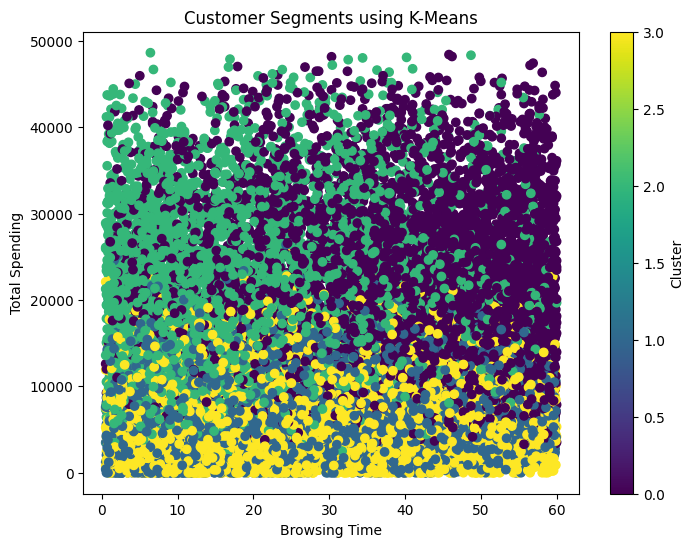

In [144]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Browsing_Time"],
    df["Total_Spending"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Browsing Time")
plt.ylabel("Total Spending")
plt.title("Customer Segments using K-Means")

plt.colorbar(label="Cluster")
plt.savefig(
    "screenshots/17_Customer_Segment_Scatter.png",
    bbox_inches="tight"
)

plt.show()

#### Check the average values for each cluster

In [145]:

df.groupby("Cluster")[[
    "Browsing_Time",
    "Previous_Purchases",
    "Rating",
    "Total_Spending",
    "Cart_Addition",
    "Discount_Applied"
]].mean()

,Browsing_Time,Previous_Purchases,Rating,Total_Spending,Cart_Addition,Discount_Applied
Cluster,,,,,,
0,38.873411,22.192582,4.247989,21143.978104,0.999303,0.494341
1,29.731913,7.817440,3.508620,7078.456562,0.593868,1.000000
2,20.596246,22.243313,4.091319,20507.988545,0.000469,0.492961
3,29.337088,7.605591,3.407120,6540.066392,0.573411,0.000000


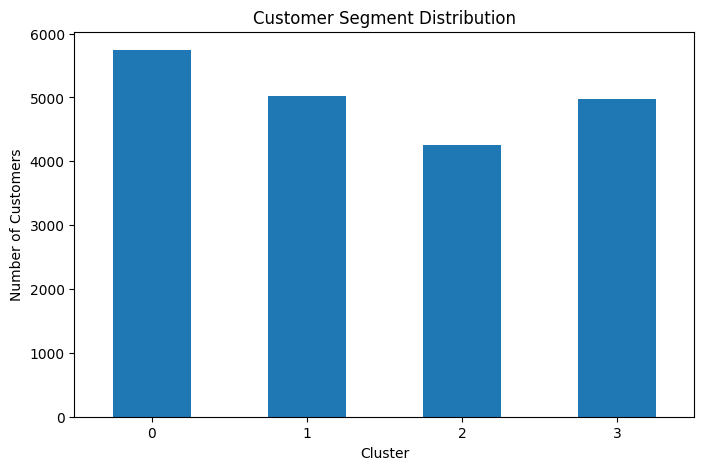

In [146]:


plt.figure(figsize=(8,5))


df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)


plt.title(
    "Customer Segment Distribution"
)


plt.xlabel(
    "Cluster"
)


plt.ylabel(
    "Number of Customers"
)


plt.xticks(rotation=0)
plt.savefig(
    "screenshots/17_Customer_Segment_diatribution.png",
    bbox_inches="tight"
)

plt.show()




In [147]:
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(cluster_scaled, df["Cluster"]))

Inertia: 68997.48736647656
Silhouette Score: 0.20071281135430522


#### EVALUATION MATRIX 

| **Metric**           | **Value**                           | **Purpose**                                   | **Interpretation**                                                                                                                                          |
| -------------------- | ----------------------------------- | --------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Elbow Method**     | **K = 4**                           | Determines the optimal number of clusters.    | The elbow point occurred at **4 clusters**, indicating that four customer segments provide a good balance between model complexity and cluster compactness. |
| **Inertia**          | **`kmeans.inertia_` (*68997.48736647656*) | Measures how compact the clusters are.        | A lower inertia value indicates that data points are closer to their respective cluster centroids, resulting in more compact clusters.                      |
| **Silhouette Score** | **`score` (0.20071281135430522)**           | Measures how well-separated the clusters are. | A higher silhouette score (closer to **1**) indicates better-defined and well-separated customer clusters.                                                  |



#### BUISNESS USE 

| **Customer Segment**             | **Business Strategy**                                                                                            |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **High-Value Customers**         | Offer loyalty rewards, exclusive memberships, and premium product recommendations to encourage repeat purchases. |
| **Discount-Sensitive Customers** | Provide coupons, promotional offers, and seasonal discounts to increase purchase likelihood.                     |
| **Browsers with Low Purchases**  | Send personalized product recommendations, reminder emails, and limited-time offers to encourage conversions.    |
| **Frequent Buyers**              | Recommend new arrivals, premium products, and subscription plans to maintain engagement and customer loyalty.    |


#### Part D: Hyperparameter Optimization

The objective of this section is to improve the performance of the machine learning models by tuning their hyperparameters. Hyperparameter tuning helps identify the best parameter values that produce the highest model accuracy and overall performance.

The following techniques are used:

- GridSearchCV for Ridge Regression
- GridSearchCV for Logistic Regression
- Elbow Method and Silhouette Analysis for K-Means Clustering

#### 1. Ridge Regression Hyperparameter Tuning

In [148]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Features
X = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Discount_Applied",
    "Age",
    "Total_Spending"
]]

# Target
y = df["Rating"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling
ridge_scaler = StandardScaler()

X_train = ridge_scaler.fit_transform(X_train)
X_test = ridge_scaler.transform(X_test)

In [149]:
ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Alpha :", grid.best_params_)
print("Best Cross Validation R² :", grid.best_score_)

Best Alpha : {'alpha': 10}
Best Cross Validation R² : 0.22955702166195247


#### 2. Logistic Regression Hyperparameter Tuning

In [150]:
X = df[[
    "Browsing_Time",
    "Cart_Addition",
    "Previous_Purchases",
    "Rating",
    "Price",
    "Discount_Applied",
    "Total_Spending"
]]

y = df["Purchase_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

log_scaler = StandardScaler()

X_train = log_scaler.fit_transform(X_train)
X_test = log_scaler.transform(X_test)

In [151]:
log_model = LogisticRegression(random_state=42)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "max_iter": [100, 200, 500]
}

grid = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Accuracy :", grid.best_score_)

c:\Users\nandi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\nandi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\nandi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

Best Parameters : {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy : 0.8338125


c:\Users\nandi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


#### K-Means Clustering Optimization

The Elbow Method and Silhouette Score are used to determine the optimal number of clusters.

The Elbow Method identifies the point where adding more clusters provides diminishing improvements.

The Silhouette Score measures how well each customer fits within its assigned cluster compared to other clusters.

In [152]:
# Prepare clustering data again

cluster_data = df[[
    "Browsing_Time",
    "Previous_Purchases",
    "Rating",
    "Total_Spending",
    "Cart_Addition",
    "Discount_Applied"
]]

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

# Train K-Means again

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(cluster_scaled)

# Calculate Silhouette Score

score = silhouette_score(
    cluster_scaled,
    df["Cluster"]
)

In [153]:
print("Optimal Number of Clusters : 4")

print("Inertia :", kmeans.inertia_)

print("Silhouette Score :", score)

Optimal Number of Clusters : 4
Inertia : 68997.48736647656
Silhouette Score : 0.20071281135430522


#### Part E: Model Evaluation and Business Alignment
In this section, the performance of all machine learning models is compared using appropriate evaluation metrics. Each model is analyzed based on its technical performance and its contribution to solving business problems in the e-commerce recommendation system.

### Model Comparison Table

| **Model** | **ML Task** | **Evaluation Metrics** | **Business Value** |
|------------|-------------|------------------------|--------------------|
| **Linear Regression** | Rating Prediction | MAE = 0.503, RMSE = 0.589, R² = 0.228 | Predicts customer ratings to recommend products users are likely to rate highly. |
| **Logistic Regression** | Purchase Prediction | Accuracy = 82.4%, Precision = 85.8%, Recall = 91.6%, F1 = 88.6%, ROC-AUC = 73.3% | Predicts whether a customer is likely to purchase a product, enabling targeted recommendations and marketing. |
| **K-Means Clustering** | Customer Segmentation | Elbow Method (K = 4), Inertia, Silhouette Score = 0.2007 | Groups customers into segments for personalized marketing and recommendation strategies. |

# Final Conclusion

The objective of this project was to develop an intelligent e-commerce recommendation system using machine learning techniques. Three machine learning approaches—Regression, Classification, and Clustering—were implemented to solve different business problems.

**Regression:**  
A Linear Regression model was developed to predict customer ratings. The model achieved an MAE of **0.503**, an RMSE of **0.589**, and an R² Score of **0.228**, indicating that it can reasonably predict customer ratings based on product and customer-related features. Ridge Regression was also optimized using GridSearchCV, where the best alpha value was **10**, improving the model's generalization.

**Classification:**  
Logistic Regression was used to predict purchase likelihood. The model achieved an **Accuracy of 82.4%**, **Precision of 85.8%**, **Recall of 91.6%**, **F1-Score of 88.6%**, and **ROC-AUC of 73.3%**. These results show that the model performs well in identifying customers who are likely to purchase a product.

**Customer Segmentation:**  
K-Means Clustering identified **4 customer segments** using the Elbow Method. These segments represent different customer behaviors, such as **Frequent Buyers, Browsers with Low Purchases, Discount-Sensitive Customers, and High-Value Customers**. Among these, **High-Value Customers** are the most valuable to the business because they contribute the highest spending and are more likely to make repeat purchases.

**Feature Importance:**  
The analysis showed that features such as **Browsing Time, Previous Purchases, Total Spending, Discount Applied, Price, and Rating** significantly influenced customer purchasing behavior and product ratings.

**Business Impact:**  
The combination of Regression, Classification, and Clustering improves the recommendation system by predicting customer ratings, identifying potential buyers, and segmenting customers for personalized marketing strategies. These models enable the e-commerce platform to recommend relevant products, improve customer satisfaction, increase sales conversions, and support data-driven business decisions.

**Evaluation Metrics:**  
Evaluation metrics such as **MAE, RMSE, R² Score, Accuracy, Precision, Recall, F1-Score, ROC-AUC, Inertia, and Silhouette Score** were used to measure model performance. These metrics helped compare the models and ensured that the selected algorithms effectively support the business objectives of the e-commerce recommendation system.

In [154]:
import os
import matplotlib.pyplot as plt

os.makedirs("screenshots", exist_ok=True)

for i, fig in enumerate(plt.get_fignums(), start=1):
    figure = plt.figure(fig)
    figure.savefig(
        f"screenshots/graph_{i}.png",
        bbox_inches="tight"
    )

print("All graphs saved successfully!")

All graphs saved successfully!
